<a href="https://colab.research.google.com/github/adityaa311/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adityaa311/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
# ==========================================
# ML-10 Setup Cell
# FlyRank Warehouse + DuckDB
# ==========================================

!pip -q install duckdb huggingface_hub

import duckdb
import pandas as pd

from huggingface_hub import snapshot_download
from google.colab import userdata

# Read Hugging Face token from Colab Secrets
HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError(
        "HF_TOKEN not found. Add your Hugging Face READ token in Colab Secrets."
    )

# Download (or reuse cached) warehouse
repo_path = snapshot_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    token=HF_TOKEN,
)

print("Warehouse location:")
print(repo_path)

# Connect DuckDB
con = duckdb.connect()

# Create views
con.sql(f"""
CREATE OR REPLACE VIEW fact_daily AS
SELECT *
FROM read_parquet(
'{repo_path}/fact_content_daily_performance/month=2026-03/*.parquet'
);
""")

con.sql(f"""
CREATE OR REPLACE VIEW dim_content AS
SELECT *
FROM read_parquet(
'{repo_path}/dim_content.parquet'
);
""")

con.sql(f"""
CREATE OR REPLACE VIEW dim_clients AS
SELECT *
FROM read_parquet(
'{repo_path}/dim_clients.parquet'
);
""")

print("Setup completed successfully!")
print(con.sql("SHOW TABLES").df())

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

Warehouse location:
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2
Setup completed successfully!
          name
0  dim_clients
1  dim_content
2   fact_daily


In [2]:
con.sql("""
SELECT
COUNT(*) AS total_rows,
MIN(report_date) AS start_date,
MAX(report_date) AS end_date
FROM fact_daily
""").df()

,total_rows,start_date,end_date
0,9841378,2026-03-01,2026-03-31


## 1. Ranked actions + reason codes

The ranked queue prioritizes content pages that may benefit from a content refresh based on historical Search Console performance.

### Action Priority

1. Refresh immediately
2. Review content quality
3. Monitor performance
4. No action required

### Reason Codes

- REFRESH_LOW_IMPRESSIONS
- REFRESH_LOW_CLICKS
- REFRESH_POOR_POSITION
- REVIEW_CONTENT
- MONITOR_ONLY

The queue is intended to support human decision-making rather than automate publishing decisions.

In [3]:
from pathlib import Path
import pandas as pd

queue = con.sql("""
SELECT
content_hash_id,
gsc_impressions,
gsc_clicks,
gsc_sum_position,

CASE
WHEN gsc_impressions < 100
AND gsc_sum_position > 20
THEN 'Refresh Immediately'

WHEN gsc_impressions < 500
THEN 'Review Content'

WHEN gsc_sum_position > 15
THEN 'Monitor'

ELSE 'No Action'
END AS action,

CASE
WHEN gsc_impressions < 100 THEN 'REFRESH_LOW_IMPRESSIONS'
WHEN gsc_sum_position > 20 THEN 'REFRESH_POOR_POSITION'
WHEN gsc_clicks < 20 THEN 'REFRESH_LOW_CLICKS'
ELSE 'MONITOR_ONLY'
END AS reason_code

FROM fact_daily

WHERE gsc_data_available IS TRUE
""").df()

queue = queue.sort_values(
    ["gsc_impressions", "gsc_sum_position"],
    ascending=[True, False]
)

queue.head(20)

,content_hash_id,gsc_impressions,gsc_clicks,gsc_sum_position,action,reason_code
1339198,content_8390ee56e6ea98ee,1,0,498,Refresh Immediately,REFRESH_LOW_IMPRESSIONS
2514508,content_13ef8874a9a1ef5e,1,0,497,Refresh Immediately,REFRESH_LOW_IMPRESSIONS
3090216,content_aacb637aa920b8ea,1,0,495,Refresh Immediately,REFRESH_LOW_IMPRESSIONS
2527896,content_c7ebdf81f488f0d8,1,0,480,Refresh Immediately,REFRESH_LOW_IMPRESSIONS
303585,content_8c34799f566ce23c,1,0,469,Refresh Immediately,REFRESH_LOW_IMPRESSIONS
2511803,content_6f6a949b6e7eb3ae,1,0,465,Refresh Immediately,REFRESH_LOW_IMPRESSIONS
148136,content_aa376cef98a5fae8,1,0,447,Refresh Immediately,REFRESH_LOW_IMPRESSIONS
2510316,content_070944208ef3a890,1,0,445,Refresh Immediately,REFRESH_LOW_IMPRESSIONS
3347585,content_74e1dddeda79c23c,1,0,444,Refresh Immediately,REFRESH_LOW_IMPRESSIONS
3353415,content_adb05a2cdd05709d,1,0,383,Refresh Immediately,REFRESH_LOW_IMPRESSIONS


## 2. Intended use and limits

### Intended Use

The playbook helps identify pages that may benefit from a content refresh using historical search performance data.

The recommendations are intended for SEO analysts and content teams.

### Limits

- Historical data cannot explain why rankings changed.
- Seasonal trends may influence recommendations.
- Recently published pages may not have enough history.
- The playbook should be used for decision support only.

In [4]:
summary = con.sql("""
SELECT
COUNT(*) AS rows,
COUNT(DISTINCT content_hash_id) AS pages,
COUNT(DISTINCT client_hash_id) AS clients
FROM fact_daily
WHERE gsc_data_available IS TRUE
""").df()

summary

,rows,pages,clients
0,3611061,176738,47


## 3. Human review + the no-go list
## Human Review

Before taking action, a reviewer should verify:

- Content freshness
- Search intent
- Business importance
- Seasonal behaviour
- Recent publication date

### No-Go List

The following should never be automated:

- Publishing new content
- Deleting pages
- Changing URLs
- Redirecting pages
- Modifying structured data without review

In [5]:
review = pd.DataFrame({

"Human Check":[
"Content quality",
"Search intent",
"Seasonality",
"Business value",
"Recent publication"
],

"Required":[
"Yes",
"Yes",
"Yes",
"Yes",
"Yes"
]

})

review

,Human Check,Required
0,Content quality,Yes
1,Search intent,Yes
2,Seasonality,Yes
3,Business value,Yes
4,Recent publication,Yes


## 4. Monitoring / retrain triggers
## Monitoring and Retraining

The playbook should be reviewed when:

- Search impressions change significantly.
- Search position changes over time.
- Website structure changes.
- Search Console data quality changes.
- New historical data becomes available.

Model retraining should occur after collecting sufficient new historical observations.

In [6]:
monitor = pd.DataFrame({

"Trigger":[
"Traffic Drop",
"Ranking Drop",
"New Data",
"Content Update",
"Quarterly Review"
],

"Action":[
"Review",
"Retrain",
"Retrain",
"Re-evaluate",
"Full Validation"
]

})

monitor

,Trigger,Action
0,Traffic Drop,Review
1,Ranking Drop,Retrain
2,New Data,Retrain
3,Content Update,Re-evaluate
4,Quarterly Review,Full Validation


## 5. Exports for the paper
## Exports

The ranked queue is exported for reuse in the research paper.

The exported files are generated automatically from this notebook and should be regenerated whenever the model or ranking logic changes.

Exports completed successfully.


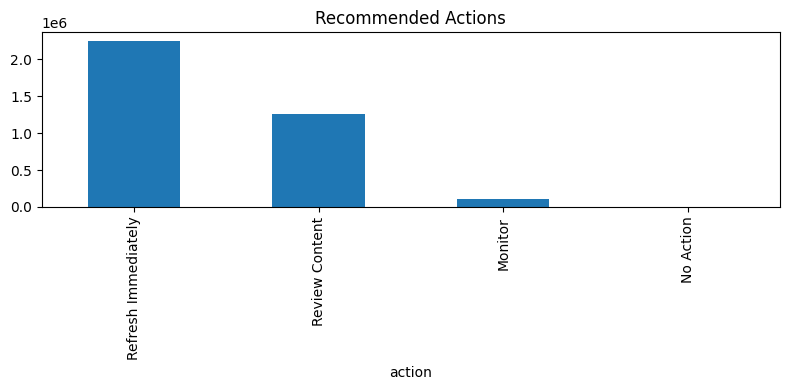

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt

Path("work/outputs").mkdir(
    parents=True,
    exist_ok=True
)

Path("work/figures").mkdir(
    parents=True,
    exist_ok=True
)

queue.to_csv(
    "work/outputs/content_action_playbook.csv",
    index=False
)

plt.figure(figsize=(8,4))

queue["action"].value_counts().plot(kind="bar")

plt.title("Recommended Actions")

plt.tight_layout()

plt.savefig(
    "work/figures/action_distribution.png"
)

print("Exports completed successfully.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.